In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci
import matplotlib.pyplot as plt
from rich.console import Console

from libdet import Hamiltonian
from detnqs.model import Backflow, RBackflow
from detnqs.vstate import MCState
from detnqs.sampler.mcmc import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import adamsr, minsr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("double")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [2]:
mol = gto.M(
    # atom=
    # '''
    # N   1.53920000,  0.00000000,  0.0000000
    # N   -0.539200000,  0.00000000,  0.0000000
    # ''',
    atom=
    '''
    O   0.00000000,  0.00000000,  0.00000000
    H   0.75700000,  0.00000000,  0.58590000
    H  -0.75700000,  0.00000000,  0.58590000
    ''',
    # atom=
    # '''
    # Li   3.732, 0.25, 0.0
    # Li   2.0, 0.25, 0.0
    # O  2.866, -0.25, 0.0
    # ''',
    basis="6-31g",
    unit="Angstrom",
    spin=0,
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Canonical MO
h1e = np.asarray(mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff, dtype=np.float64)
eri = np.asarray(ao2mo.restore(8, ao2mo.kernel(mol, mf.mo_coeff), norb), dtype=np.float64)

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

# e_fci = -109.099941428008 # N2_631g
# e_fci = -87.892693 # Li2O_sto3g

solver = fci.direct_spin1.FCI(mol)
solver.nroots = 2
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
e_fci = e_fci[0]
s2, mult = fci.spin_op.spin_square(ci[0], norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

SCF energy : -75.983997609010
FCI energy : -76.120842435452
S^2  : 0.000000


In [3]:
model = RBackflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,))

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=0,
    proposal="ham",
    blur=0.5,
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="hf",
    key=jax.random.key(0),
)

steps = 1000

optimizer = optax.chain(
    adamsr(shift=1e-2),
    optax.scale(-5e-2)
)

E0602 18:06:34.988274   68299 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0602 18:06:34.997904   67527 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


-----------------------------------------------------------------------------------------------
Step       Energy        |E-E0|       Var      Acc     ESS     N_u     N_f    alpha    SR cond 
-----------------------------------------------------------------------------------------------
  0      -75.984557     1.36e-01   4.26e-01    0.0%   49.7%    283    34536   1.000   4.79e+03 
 10      -76.095132     2.57e-02   8.14e-03   30.2%   21.7%    636    130550  0.414   4.32e+01 
 20      -76.098592     2.23e-02   4.78e-02   37.3%    8.5%    859    196036  0.532   7.02e+01 
 30      -76.107953     1.29e-02   9.50e-02   40.2%    4.3%    927    219981  0.635   8.70e+01 
 40      -76.109025     1.18e-02   2.28e-02   34.6%    3.7%    945    233660  0.716   1.01e+02 
 50      -76.111169     9.67e-03   2.61e-02   37.9%    3.4%    944    235758  0.776   2.94e+02 
 60      -76.113714     7.13e-03   5.89e-02   34.0%    2.4%    960    235142  0.819   1.10e+03 
 70      -76.115973     4.87e-03   3.92e

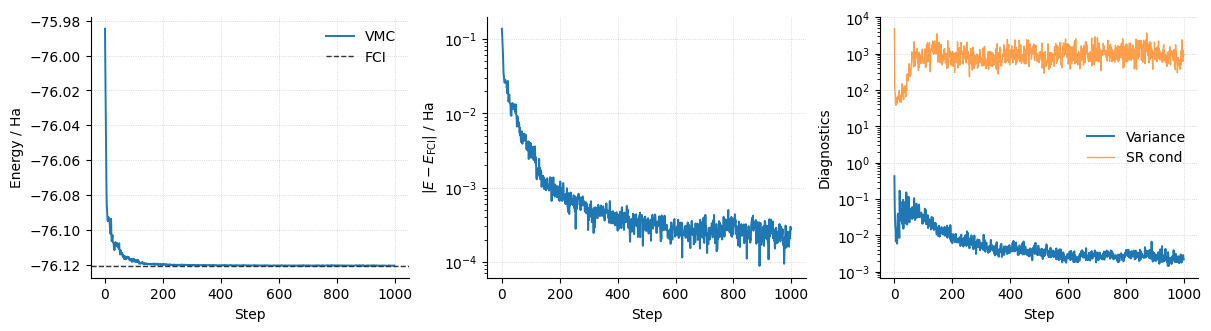

In [4]:
from collections import defaultdict

METRICS = {
    "step": ("Step", "d", 5),
    "energy": ("Energy", ".6f", 14),
    "error": ("|E-E0|", ".2e", 10),
    "variance": ("Var", ".2e", 9),
    "accept": ("Acc", ".1%", 6),
    "ess_frac": ("ESS", ".1%", 6),
    "n_unique": ("N_u", ".0f", 6),
    "n_eval": ("N_f", ".0f", 6),
    "alpha": ("alpha", ".3f", 6),
    "sr_cond": ("SR cond", ".2e", 9),
}

header = "  ".join(f"{label:^{width}}" for label, _, width in METRICS.values())
line = "-" * len(header)

print(line, header, line, sep="\n")

vmc = VMC.init(state, optimizer)
history = []
total_times = defaultdict(float)

for step in range(steps):
    stats = vmc.step()
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(dict(stats))
    
    for k, v in stats.items():
        if k.startswith("time_"):
            total_times[k.removeprefix("time_")] += float(v)
            
    if step % 10 == 0 or step == steps - 1:
        row_cells = []
        for k, (_, fmt, width) in METRICS.items():
            val = stats.get(k, 0.0)
            formatted_val = f"{int(val):{fmt}}" if fmt == "d" else f"{float(val):{fmt}}"
            row_cells.append(f"{formatted_val:^{width}}")
        print("  ".join(row_cells))

print(line)

if total_times:
    items = sorted(
        ((k, v) for k, v in total_times.items() if k != "total"),
        key=lambda x: x[1],
        reverse=True
    )
    print("Time:", "  ".join(f"{k}={v:.2f}s" for k, v in items))
    print(line)


hist = {k: np.asarray([s.get(k, np.nan) for s in history]) for k in METRICS}
x = hist["step"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), constrained_layout=True)

axes[0].plot(x, hist["energy"], lw=1.4, label="VMC")
axes[0].axhline(e_fci, ls="--", lw=1.0, c="0.2", label="FCI")
axes[0].set(xlabel="Step", ylabel="Energy / Ha")
axes[0].legend(frameon=False)

axes[1].semilogy(x, np.maximum(hist["error"], 1e-16), lw=1.4)
axes[1].set(xlabel="Step", ylabel=r"$|E-E_\mathrm{FCI}|$ / Ha")

axes[2].semilogy(x, np.maximum(hist["variance"], 1e-16), lw=1.4, label="Variance")
if "sr_cond" in hist:
    axes[2].semilogy(x, hist["sr_cond"], lw=1.0, alpha=0.75, label="SR cond")
axes[2].set(xlabel="Step", ylabel="Diagnostics")
axes[2].legend(frameon=False)

for ax in axes:
    ax.grid(True, ls=":", lw=0.6, alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)

plt.show()